## Notebook to create a weekly summarize of immigration and refugee law jurisprudence

Citation: Simon Wallace, "Notebook to make a weekly summary of immigration and refugee law jurisprudence" (2025), online: <https://github.com/a2aj-ca/canadian-legal-data/example-projects/fc_summarizer.ipynb>.

### Setup: install packages

In [1]:
# !pip install datasets
# !pip install pandas
# !pip install matplotlib 
# !pip install seaborn
# !pip install openai

### Example 1: Calculating the weekly mean/median number of words released by the Federal Court of Canada concerning refugee and immigration law

In [2]:
# load packages
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
laws = load_dataset("a2aj/canadian-case-law", data_dir="FC", split="train")
df = laws.to_pandas()

In [3]:
# filter for cases where the word "immigration" appears in the case name
df = df[df['name_en'].str.contains('immigration', case=False).fillna(False)].reset_index(drop=True)

# extract the year and the week the decision was rendered
df['year'] = df['document_date_en'].dt.year
df['week'] = df['document_date_en'].dt.isocalendar().week

# count the number of words in the decision
df['word_count'] = df['unofficial_text_en'].str.split().apply(len)

/tmp/ipykernel_6776/661630.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df[df['name_en'].str.contains('immigration', case=False).fillna(False)].reset_index(drop=True)


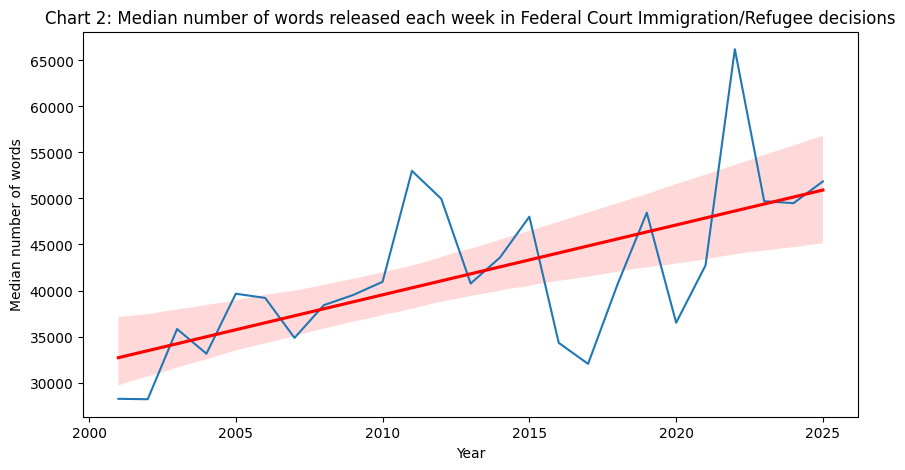

In [4]:
# calculate weekly sums
weekly = df.groupby(['year','week'])['word_count'].sum().reset_index()
weekly = weekly.groupby('year')['word_count'].median().reset_index()
weekly.set_index('year', inplace=True)

# plot, with a regression line, the median number of words released by the Federal Court in immigration/refugee decisions
plt.figure(figsize=(10,5))
sns.lineplot(data=weekly)
sns.regplot(x=weekly.index, y=weekly['word_count'], scatter=False, color='red')

plt.title('Chart 2: Median number of words released each week in Federal Court Immigration/Refugee decisions')
plt.xlabel('Year')
plt.ylabel('Median number of words')
plt.legend([],[], frameon=False)

### Example 2: Summarize the weekly output, make a memo, and produce a podcast

In [ ]:
from openai import OpenAI
import json
import textwrap
from pathlib import Path

# load the client
client = OpenAI()

# prompt to extract information and summarize cases where an error was found
prompt = """Read a Federal Court of Canada case and extract the following information:

- Determine whether the judicial review was allowed (granted) or dismissed (denied).
- Identify the last name of the judge who issued the decision.
- Identify what the underlying decision concerned (e.g., RPD, RAD, PRRA, IAD, H+C, Economic, etc.).
- Summarize the relevant facts of the case in a concise paragraph.
- If the judicial review was allowed (the application was successful), summarize the error identified by the judge that led to the judicial review being granted.

Before producing the final answer, think step-by-step:
1. Carefully review the entire case to understand the context, decision, and reasoning.
2. Locate the section indicating the outcome (whether the judicial review was allowed or dismissed), and extract the relevant language.
3. Identify the last name of the judge from the case heading or decision section.
4. Identify what the underlying decision concerned (e.g., RPD, RAD, PRRA, IAD, H+C, Economic, etc.).
5. Identify and concisely summarize the main facts of the case.
6. If the judicial review was allowed, find and summarize the error or errors cited by the judge.
7. Ensure that all outputs are in the correct order: reasoning/explanation comes before any final conclusion, classification, or result.

Persist until all objectives are fully completed.

Format your response as a structured JSON object with the following fields:

{
  "reasoning": {
    "how_judicial_review_outcome_was_identified": "[Step-by-step explanation of how you identified the outcome]",
    "how_judge_was_identified": "[Step-by-step explanation of how you identified the judge's last name]",
    "how_underlying_decision_was_identified": "[Step-by-step explanation of how you identified what the underlying decision concerned]",
    "summary_of_facts": "[Concise paragraph summarizing the facts, including key details and parties]",
    "how_error_was_identified_if_allowed": "[If allowed, step-by-step explanation of how the error was found and summarized. If not allowed, state 'N/A']"
  },
  "conclusion": {
    "judicial_review_outcome": "[Allowed/Dismissed]",
    "judge_last_name": "[Judge's Last Name]",
    "underlying_decision_type": "[e.g., RPD, RAD, PRRA, IAD, H+C, Economic, etc.]",
    "facts_summary": "[Succinct summary of facts]",
    "error_summary_if_allowed": "[Summary of the error(s) that led to granting judicial review, or 'N/A' if not allowed]"
  }
}

—Example Input—
Federal Court case: [Insert detailed case text here]

—Example Output—  
(reasoning always precedes conclusion in output)

{
  "reasoning": {
    "how_judicial_review_outcome_was_identified": "The decision section of the case states, 'The judicial review is allowed.'",
    "how_judge_was_identified": "At the top of the decision and at the end, the decision is signed by 'Justice Jane Smith', so the last name 'Smith' was extracted.",
    "how_underlying_decision_was_identified": "The case text references the original proceeding as a PRRA decision (Pre-Removal Risk Assessment), which is identified in the introduction.",
    "summary_of_facts": "The applicant, a permanent resident, challenged a deportation order issued after a criminal conviction. The central issue was whether procedural fairness was observed during the immigration hearing.",
    "how_error_was_identified_if_allowed": "The judge identified that the Tribunal failed to consider key exculpatory evidence, resulting in procedural unfairness. This error directly led to the judicial review being granted."
  },
  "conclusion": {
    "judicial_review_outcome": "Allowed",
    "judge_last_name": "Smith",
    "underlying_decision_type": "PRRA",
    "facts_summary": "The applicant contested a deportation order after a criminal conviction, alleging a breach of procedural fairness at the immigration tribunal.",
    "error_summary_if_allowed": "The Tribunal's failure to consider critical exculpatory evidence constituted a breach of procedural fairness."
  }
}

(Real case facts and error summaries may be multiple paragraphs or highly detailed. Use concise language and relevant detail, but keep responses within 2–3 short paragraphs per section.)

Important objective reminder:  
- Always begin with step-by-step reasoning in each field before stating conclusions and classifications.
- Output must be in the specified JSON structure, in the order given."""

# function to analyze a case
def analyze_case(case_text: str, prompt, model="gpt-5-mini") -> None:
    response = client.responses.create(
    model=model,
    input=[
        {
        "role": "developer",
        "content": [
            {
            "type": "input_text",
            "text": prompt
            }
        ]
        },
        {
        "role": "user",
        "content": [
            {
            "type": "input_text",
            "text": case_text
            }
        ]
        }
    ],
    text={
        "format": {
        "type": "text"
        },
        "verbosity": "medium"
    },
    reasoning={
        "effort": "medium"
    },
    tools=[],
    store=True,
    include=[
        "reasoning.encrypted_content",
        "web_search_call.action.sources"
    ]
    )
    return response

In [23]:
# isolate for cases decided in the most recent week
last_year = df['year'].max()
last_week = df[df['year']==last_year]['week'].max()

most_recent = df[(df['year']==last_year) & (df['week']==last_week)].copy().reset_index(drop=True)

# analyze the cases
for idx,row in most_recent.iterrows():
    print(f"Analyzing case {idx+1} of {most_recent.shape[0]}")
    res = analyze_case(row['unofficial_text_en'], prompt)
    answers = json.loads(res.output[1].content[0].text)['conclusion']
    #add to df
    for key in answers:
        most_recent.loc[idx, key] = answers[key]

Analyzing case 1 of 13
Analyzing case 2 of 13
Analyzing case 3 of 13
Analyzing case 4 of 13
Analyzing case 5 of 13
Analyzing case 6 of 13
Analyzing case 7 of 13
Analyzing case 8 of 13
Analyzing case 9 of 13
Analyzing case 10 of 13
Analyzing case 11 of 13
Analyzing case 12 of 13
Analyzing case 13 of 13


In [91]:
errors_established

,dataset,citation_en,citation2_en,name_en,document_date_en,url_en,scraped_timestamp_en,unofficial_text_en,citation_fr,citation2_fr,...,unofficial_text_fr,upstream_license,year,week,word_count,judicial_review_outcome,judge_last_name,underlying_decision_type,facts_summary,error_summary_if_allowed
0,FC,2025 FC 1449,,Ahmed v. Canada (Citizenship and Immigration),2025-09-02 00:00:00+00:00,https://decisions.fct-cf.gc.ca/fc-cf/decisions...,2025-09-04 09:02:12.667000+00:00,Ahmed v. Canada (Citizenship and Immigration)\...,None,None,...,None,"See upstream license, including non-commercial...",2025,36,799,Allowed,Grammond,Economic (work permit refusal; consequential v...,"Ahmed, a Pakistani national with a bachelor's ...",The officer unreasonably focused on the applic...
1,FC,2025 FC 1427,,Cabral v. Canada (Citizenship and Immigration),2025-09-04 00:00:00+00:00,https://decisions.fct-cf.gc.ca/fc-cf/decisions...,2025-09-06 09:01:29.793000+00:00,Cabral v. Canada (Citizenship and Immigration)...,None,None,...,None,"See upstream license, including non-commercial...",2025,36,1049,Allowed,Turley,H+C (Humanitarian and Compassionate) / BIOC (B...,A minor Dominican citizen was excluded from hi...,The judge found the officer failed to meaningf...
2,FC,2025 FC 1470,,Rajamanickam v. Canada (Citizenship and Immigr...,2025-09-05 00:00:00+00:00,https://decisions.fct-cf.gc.ca/fc-cf/decisions...,2025-09-06 09:01:07.373000+00:00,Rajamanickam v. Canada (Citizenship and Immigr...,None,None,...,None,"See upstream license, including non-commercial...",2025,36,1382,Allowed,Grant,RAD (confirmation of RPD decision on refugee c...,"Rajamanickam, a citizen of India and former AI...",The RAD unreasonably characterized undisputed ...


In [92]:
# isolate cases where an error was found
errors_established = most_recent[most_recent['judicial_review_outcome']=='Allowed'].copy()
errors_established.sort_values(by='underlying_decision_type', inplace=True)
errors_established.reset_index(drop=True, inplace=True)

num_cases_week = most_recent.shape[0]
num_cases_week_errors = errors_established.shape[0]

total_words = most_recent['word_count'].sum()

memo_prompt = f"""You are a legal research assistant. Based on the data provided, draft a readable memorandum for a smart but busy Canadian immigration/Refugee lawyers.
You will be shown cases where, in the last week, the Federal Court allowed (granted) judicial review.
Summarize the facts and the key error(s) identified by the judge that led to the judicial review being allowed.
For each case, include the title, judge, and underlying decision type (e.g., RPD, RAD, PRRA, IAD, H+C, Economic, etc.), and then in a sentence or two summarize the facts and then a few more sentences the error(s) identified.
Begin the memorandum with a brief overview. Tell the reader how many cases were decided in total, how many allowed (granted) judicial review, and the total number of words released.
Summarize the key themes. This is just a brief intro to orient the reader. Tell them if the cases dealt mostly with the assessment of the evidence, or procedural fairness, or interpretation of statutes, etc.

Your memo should be written in plain, clear, and direct language, suitable for a busy professional audience. Avoid overuse of legal jargon and overuse of bullets.

Here is some information. The total number of immigration and refugee cases decided by the Federal Court in the last week was {num_cases_week}. The number of cases where judicial review was allowed (granted) was {num_cases_week_errors}. The total number of words released in all decisions was {total_words}."""

cases = ""

for idx,row in errors_established.iterrows():
    case_info = f"""{idx+1}. {row['name_en']} | citation: {row['citation_en']} | Judge: {row['judge_last_name']} | Underlying decision: {row['underlying_decision_type']}
    Case: {row['unofficial_text_en']}
    -----------------
    """
    cases += case_info

res = analyze_case(cases, memo_prompt, model="gpt-5")

text = res.output[1].content[0].text
print('\n'.join(textwrap.fill(line, width=80) for line in text.splitlines()))

Memorandum — Federal Court Immigration/Refugee Judicial Reviews (Week in Review)

Overview
- Total FC immigration/refugee decisions: 13
- Judicial reviews allowed: 3
- Total words released: 24,264

Themes this week: reasonableness and evidence assessment dominated. The Court
allowed three applications where decision-makers (1) misapplied or misunderstood
regulatory/occupational requirements, (2) failed to meaningfully grapple with
central evidence and best interests of the child (BIOC) submissions on an H+C
request, and (3) mischaracterized unchallenged evidence in an Internal Flight
Alternative (IFA) analysis. Vavilov’s demands for responsive, evidence‑based
justification were front and centre; no certified questions were issued.

Case Summaries

1) Ahmed v. Canada (Citizenship and Immigration), 2025 FC 1449 (Grammond J.)
Underlying decision type: Economic (work permit refusal; consequential refusal
of spouse’s work permit and child’s TRV)

Facts in brief
- Pakistani applicant sought 

In [93]:
podcast_prompt = f"""You are a podcast scriptwriter for busy legal professionals. Create a conversational, engaging podcast script summarizing the most recent Court decisions, focusing on key errors found and their broader legal significance. Imagine your audience is intelligent but pressed for time—listening in their cars—and seeking a quick yet substantive digest so they can decide if any cases warrant further reading.

Your task is to:

- Open by reminding listeners that the podcast is AI-generated, not legal advice, and only a summary.
- Briefly summarize overall stats: the number and type of decisions released last week (e.g., "Last week, the Court released X immigration and refugee decisions, totaling Y words. Judicial review was allowed in Z cases").
- Highlight common themes or notable case trends (e.g., repeated breaches of procedural fairness, misinterpretations of law, or a mix of errors). If there is a particularly significant case, lead with it.
- For each granted (allowed) case, present a concise yet story-driven summary:
  - Start with the most important or interesting case.
  - Share a compelling, easy-to-follow narrative of the case.
  - Focus on the error(s) identified by the judge that led to judicial review being allowed.
  - Mention the case by party names; omit the citation (say “see show notes” instead).
- Avoid legalese, unneeded details, direct repetition from memos, humour, and excessive bullet points.
- Ask rhetorical questions or use metaphors/analogies to clarify complex issues and keep the tone lively and professional.
- Give listeners just enough to decide if they want to dive deeper into the full decisions.
- Do not use section headings in the script; it should be a single flowing narrative.

**Output Format:**  
- Produce a single, concise yet comprehensive podcast script, written in an engaging, conversational style (around 3-6 medium paragraphs, depending on content), with no section headings.
- All reasoning should be worked into the narrative flow, never stated as bullet points or out-of-character.
- Never cite directly from the case; mention party names only and refer listeners to the show notes for details.
- ALWAYS begin with reasoning (setup, context, key themes, trends), then present cases in descending order of interest/importance. Only provide conclusions, opinions, or takeaways at the end of each case (never upfront).

**Example (shortened for illustration; real outputs should be longer with more detail):**
  
“Last week there were 10 decisions. In one case, Smith v. Canada, judicial review was allowed due to failure to consider key evidence… In Doe v. Canada, the judge found a misapplication of law… In others, decisions were upheld...”

Example Output:  
“Welcome to this week’s AI-generated podcast—your quick legal briefing while you’re on the go. Remember, this isn’t legal advice, just an overview to keep you informed about what the Court’s been up to. Last week, the Court handed down 10 new decisions in the immigration and refugee law sphere. Only a couple of cases saw judicial reviews allowed—so let’s take a closer look at the errors the Court saw.

etc”

(Real examples should include more narrative detail, varied rhetorical devices, and deeper explanation of themes or recurring patterns when warranted.)

**Important Reminders:**
- Focus on errors found, trends, or major takeaways that reflect broader legal significance.
- Never use headings. Always maintain a flowing narrative.
- Place all summary reasoning, context, and themes before case-by-case conclusions.
- Only use party names; mention citations are in the show notes.
- Keep tone engaging, professional, and easy to follow for busy legal listeners.
- Remember, these are experts in Canadian immigration law. Treat them as such.
- Do not use acronyms.
- Spell out numbers.

**Legal background:**
Follow the framework in Vavilov when explaining judicial review.
Reasonableness review is methodologically distinct from correctness review. The court conducting a reasonableness review must focus on the decision the administrative decision maker actually made, including the justification offered for it. A court applying the reasonableness standard does not ask what decision it would have made in place of the administrative decision maker, attempt to ascertain the range of possible conclusions, conduct a new analysis or seek to determine the correct solution to the problem. Instead, the reviewing court must consider only whether the decision made by the decision maker, including both the rationale for the decision and the outcome to which it led, was unreasonable.

                    In cases where reasons are required, they are the starting point for reasonableness review, as they are the primary mechanism by which decision makers show that their decisions are reasonable. Reasons are the means by which the decision maker communicates the rationale for its decision: they explain how and why a decision was made, help to show affected parties that their arguments have been considered and that the decision was made in a fair and lawful manner, and shield against arbitrariness. A principled approach to reasonableness review is therefore one which puts those reasons first. This enables a reviewing court to assess whether the decision as a whole is reasonable. Attention to the decision maker’s reasons is part of how courts demonstrate respect for the decision‑making process.

                    In many cases, formal reasons for a decision will not be given or required. Even without reasons, it is possible for the record and the context to reveal that a decision was made on the basis of an improper motive or for another impermissible reason. There will nonetheless be situations in which neither the record nor the larger context sheds light on the basis for the decision. In such cases, the reviewing court must still examine the decision in light of the relevant factual and legal constraints on the decision maker in order to determine whether the decision is reasonable.

                    It is conceptually useful to consider two types of fundamental flaws that tend to render a decision unreasonable. The first is a failure of rationality internal to the reasoning process. To be reasonable, a decision must be based on an internally coherent reasoning that is both rational and logical. A failure in this respect may lead a reviewing court to conclude that a decision must be set aside. Reasonableness review is not a line‑by‑line treasure hunt for error. However, the reviewing court must be able to trace the decision maker’s reasoning without encountering any fatal flaws in its overarching logic. Because formal reasons should be read in light of the record and with due sensitivity to the administrative regime in which they were given, a decision will be unreasonable if the reasons for it, read holistically, fail to reveal a rational chain of analysis or if they reveal that the decision was based on an irrational chain of analysis. A decision will also be unreasonable where the conclusion reached cannot follow from the analysis undertaken or if the reasons read in conjunction with the record do not make it possible to understand the decision maker’s reasoning on a critical point. Similarly, the internal rationality of a decision may be called into question if the reasons exhibit clear logical fallacies.

                    The second type of fundamental flaw arises when a decision is in some respect untenable in light of the relevant factual and legal constraints that bear on it. Although reasonableness is a single standard that already accounts for context, and elements of a decision’s context should not modulate the standard or the degree of scrutiny by the reviewing court, what is reasonable in a given situation will always depend on the constraints imposed by the legal and factual context of the particular decision under review. These contextual constraints dictate the limits and contours of the space in which the decision maker may act and the types of solutions it may adopt. The governing statutory scheme, other relevant statutory or common law, the principles of statutory interpretation, the evidence before the decision maker and facts of which the decision maker may take notice, the submissions of the parties, the past practices and decisions of the administrative body, and the potential impact of the decision on the individual to whom it applies, are all elements that will generally be relevant in evaluating whether a given decision is reasonable. Such elements are not a checklist; they may vary in significance depending on the context and will necessarily interact with one another.

                    Accordingly, a reviewing court may find that a decision is unreasonable when examined against these contextual considerations. Because administrative decision makers receive their powers by statute, the governing statutory scheme is likely to be the most salient aspect of the legal context relevant to a particular decision. A proper application of the reasonableness standard is capable of allaying the concern that an administrative decision maker might interpret the scope of its own authority beyond what the legislature intended. Whether an interpretation is justified will depend on the context, including the language chosen by the legislature in describing the limits and contours of the decision maker’s authority.

                    Both statutory and common law will also impose constraints on how and what an administrative decision maker can lawfully decide. Any precedents on the issue before the administrative decision maker or on a similar issue, as well as international law in some administrative decision making contexts, will act as a constraint on what the decision maker can reasonably decide. Whether an administrative decision maker has acted reasonably in adapting a legal or equitable doctrine involves a highly context‑specific determination.

                    Matters of statutory interpretation are not treated uniquely and, as with other questions of law, may be evaluated on a reasonableness standard. Where this is the applicable standard, the reviewing court does not undertake a de novo analysis of the question or ask itself what the correct decision would have been. But an approach to reasonableness review that respects legislative intent must assume that those who interpret the law, whether courts or administrative decision makers, will do so in a manner consistent with the modern principle of statutory interpretation. Administrative decision makers are not required to engage in a formalistic statutory interpretation exercise in every case. But whatever form the interpretive exercise takes, the merits of an administrative decision maker’s interpretation of a statutory provision must be consistent with the text, context and purpose of the provision.

                    Furthermore, the decision maker must take the evidentiary record and the general factual matrix that bears on its decision into account, and its decision must be reasonable in light of them. The reasonableness of a decision may be jeopardized where the decision maker has fundamentally misapprehended or failed to account for the evidence before it. The reasons must also meaningfully account for the central issues and concerns raised by the parties, even though reviewing courts cannot expect administrative decision makers to respond to every argument or line of possible analysis.

                    While administrative decision makers are not bound by their previous decisions, they must be concerned with the general consistency of administrative decisions. Therefore, whether a particular decision is consistent with the administrative body’s past decisions is also a constraint that the reviewing court should consider when determining whether an administrative decision is reasonable. Finally, individuals are entitled to greater procedural protection when the decision in question involves the potential for significant personal impact or harm. Where the impact of a decision on an individual’s rights and interests is severe, the reasons provided to that individual must reflect the stakes. The principle of responsive justification means that if a decision has particularly harsh consequences for the affected individual, the decision maker must explain why its decision best reflects the legislature’s intention.

**Task Objective and Key Instructions (REPEAT):**  
Write an engaging, flowing podcast script, for smart busy lawyers listening in their cars. Start with high-level stats and themes, highlight errors found, lead with the most significant or interesting case, summarize the error(s) and context for each granted review, avoid headings, legal jargon, and humour. Include only party names; refer to show notes for full citations. Summary, not legal advice. Focus on narrative and clarity over detail.

Also make sure to tell the listener what week it is. So you can get the date right, these cases were released the week of {most_recent['document_date_en'].min().strftime('%B %d, %Y')}.

Here is the memo to work from: {text}"""

res = analyze_case(cases, podcast_prompt, model="gpt-5")
script = res.output[1].content[0].text

In [94]:
# create podcast file from the script
speech_file_path = Path("podcast.mp3")

with client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="cedar",
    input=script,
    instructions="Speak in an emotive, friendly, but professional tone. Imagine that you are a thorough but approachable third year lawyer. Expert, but not pompous.",
) as response:
    response.stream_to_file(speech_file_path)